In [1]:
import firedrake
import numpy as np
import pickle as pkl
from numpy import pi as π
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from firedrake import *
from firedrake import Constant, inner, sqrt, tr, grad, div, as_vector, exp,sym, as_vector, dx, ds, Mesh, Function, project, TransferManager, RectangleMesh, ExtrudedMesh, FunctionSpace, Function, SpatialCoordinate, FiniteElement
import meshpy, meshpy.geometry, meshpy.triangle
import irksome
from irksome import Dt
from scipy.signal import detrend
import copy
import matplotlib
import irksome
from irksome import Dt
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import pickle as pkl
import tqdm
import emcee
import corner
import itertools
import xarray
import dtscalibration
import glob
from rasterio.plot import show
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import os
import sys
from pyproj import Transformer
import math
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from scripts.AH_temp_funcs import *

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import shapefile as sf

import rasterio
from rasterio.enums import Resampling
from rasterio.mask import mask

import sklearn
from sklearn.metrics import r2_score
from brokenaxes import brokenaxes


### Import our homemade functions ###
import scripts.model_modules
from scripts.mesh_generating import *


# %matplotlib widget

## 0. Load the necessary data

### Borehole locations

In [2]:
### Load boreholes
borehole_locations = pd.read_csv('Borehole_Locations/Borehole_locations_DTS.csv')
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3031", always_xy=True)
transformed_x, transformed_y = transformer.transform(borehole_locations['E'], borehole_locations['S'])


### Making/Loading the fine mesh

In [3]:
upscale_factor_fine = 1/10
src_bed_fine_path = "Meshes/crop_aoi/main_boreholes_aoi/main_boreholes_aoi_fix_bed.tif"
src_surf_fine_path = "Meshes/crop_aoi/main_boreholes_aoi/main_boreholes_aoi_fix_surf.tif"
layer_num=5

mesh_fine = mesh_creator(src_bed_fine_path, src_surf_fine_path, resamp_factor=upscale_factor_fine, layers=layer_num)
mesh_fine.tolerance = 1e-10
x_src, y_src, z_src = SpatialCoordinate(mesh_fine)

pressure_space = firedrake.FunctionSpace(mesh_fine, "CG", 1)
velocity_space = firedrake.VectorFunctionSpace(mesh_fine, "CG", 3)
Y = velocity_space * pressure_space
flow = firedrake.Function(Y)

chk = DumbCheckpoint("Saved_Models/fine_mesh_flow_80.0m_updated_viscosity", mode=FILE_READ)
chk.load(flow, name="fine_mesh_flow")

/opt/firedrake/firedrake/checkpointing.py:103: DeprecationWarning: DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.",


# Get geochem and ages

In [4]:
xl = pd.ExcelFile('geochem_data/argon_and_water_iso_for_JM.xlsx')


In [5]:
fractionation_data = {}
core_ages_dict = {}

for sheet_name in xl.sheet_names[:-1]:
    df = pd.DataFrame(xl.parse(sheet_name))

    filtered_df = df[df['Argon age (ka)'] < 1500]
    
    fractionation_data[sheet_name] = [np.mean(filtered_df['δ38/36Ar (‰)']), 
                                    np.mean(filtered_df['del18OSMOW']), 
                                    np.std(filtered_df['δ38/36Ar (‰)']) / np.sqrt(len(filtered_df['δ38/36Ar (‰)'])),
                                    np.std(filtered_df['del18OSMOW']) / np.sqrt(len(filtered_df['del18OSMOW'])),
                                    ]

    core_ages_dict[sheet_name] = np.max(df['Argon age (ka)'])/1000

### Flow field

In [6]:
#enhancement factor
enhancement_factor = 1.97

In [7]:
core_age_all = []
speed_all = []
core_names_all = []

z_vals = mesh_fine.coordinates.dat.data_ro[:,2]
depth_values = np.arange(z_vals.min(), z_vals.max(), 1)

for x_bore,y_bore,age, core_name in zip(transformed_x, transformed_y, borehole_locations['oldest ice'], borehole_locations['Core']):
    if core_name == 'ALHIC1903':
        continue
    if core_name == 'ALHIC2401':
        continue
    if core_name == 'PICO2201':
        continue
    sampled_speed_prof = []
    z_depth_prof = []

    for z_bore in depth_values:
        try:
            vels = flow.at((x_bore, y_bore, z_bore))
        except:
            continue
        sampled_speed = np.sqrt(vels[0][0]**2 + vels[0][1]**2 + vels[0][2]**2)*spy*1000*enhancement_factor
        sampled_speed_prof.append(sampled_speed)
        z_depth_prof.append(z_bore)

    z_depth_prof = np.array(z_depth_prof)
    sampled_speed_prof = np.array(sampled_speed_prof)

    speed_all.append(float(sampled_speed_prof[10]))

    core_age_all.append(core_ages_dict[core_name])
    
    core_names_all.append(core_name)


# Get the line of best fit

In [9]:


# ### We do this again so we can take out the CDS cores from the best fit ###
core_age = []
speed = []
core_names = []


for x_bore,y_bore, core_name in zip(transformed_x, transformed_y,  borehole_locations['Core']):
    if core_name == 'ALHIC2301':
        continue
    if core_name == 'PICO2201':
        continue
    if core_name == 'ALHIC1903':
        continue
    if core_name == 'ALHIC2401':
        continue
    sampled_speed_prof = []
    z_depth_prof = []

    for z_bore in depth_values:
        try:
            vels = flow.at((x_bore, y_bore, z_bore))
        except:
            continue
        sampled_speed = np.sqrt(vels[0][0]**2 + vels[0][1]**2 + vels[0][2]**2)
        sampled_speed_prof.append(sampled_speed)
        z_depth_prof.append(z_bore)

    z_depth_prof = np.array(z_depth_prof)
    sampled_speed_prof = np.array(sampled_speed_prof)

    speed.append(float(sampled_speed_prof[10]*spy*1000*enhancement_factor))

    core_age.append(core_ages_dict[core_name])
    
    core_names.append(core_name)



mask = ~np.isnan(core_age) & ~np.isnan(speed)
core_age_mask = np.array(core_age)[mask]
speed_mask = np.array(speed)[mask]

slope,intercept = np.polyfit(core_age_mask, speed_mask, 1)  
best_fit  = slope * core_age_mask + intercept

r_squared = r2_score(speed_mask, best_fit)
order = np.argsort(core_age_mask)

## 1. Plot the ice core age and flow speed relationship

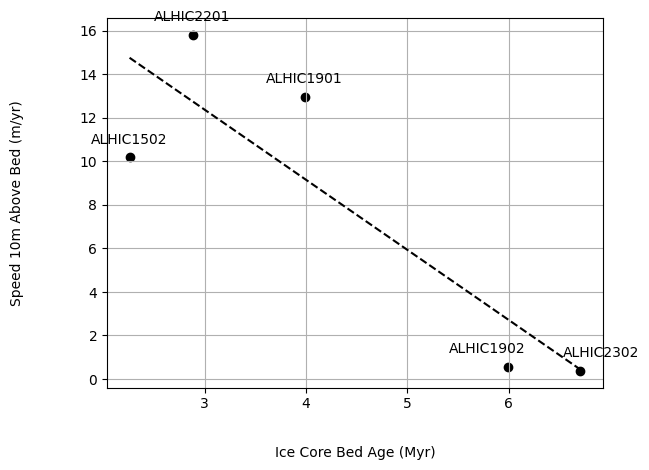

In [10]:

fig,ax = plt.subplots()
# fig = plt.figure(figsize=(7, 5))
# ax = brokenaxes(ylims=((-0.001, 0.006), (0.015, 0.020)), hspace=0.25)
ax.scatter(core_age, speed, marker='o', c='black')

for txt, x_fig_loc, y_fig_loc in zip(core_names, core_age, speed):
    if txt == 'ALHIC2302':
        ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(15,10), ha='center')
    elif txt == 'ALHIC1902':
        ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(-15,10), ha='center')
    else:
        ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(0,10), ha='center')




ax.plot(core_age_mask[order],best_fit[order], ls='--', color='black') 
# ax.set_yscale('log')
# ax.set_xscale('log')

ax.set_ylabel('Speed '+str(10)+'m Above Bed (m/yr)', labelpad=40)
ax.set_xlabel('Ice Core Bed Age (Myr)', labelpad=25)


ax.grid()

# ax.set_xlim([0.5, 7.5])
# ax.set_ylim([-0.001, 0.037])

# ax.annotate('Line of Best Fit', xy=(1, .0092), rotation=-26)



# # plt.savefig('Figures/fig3_updated_80m.eps', dpi=300, transparent=True, format='eps')
# # plt.savefig('Figures/fig3_updated_80m.png', dpi=300, transparent=False, format='png')


Text(0.5, 0, 'Age (Mya)')

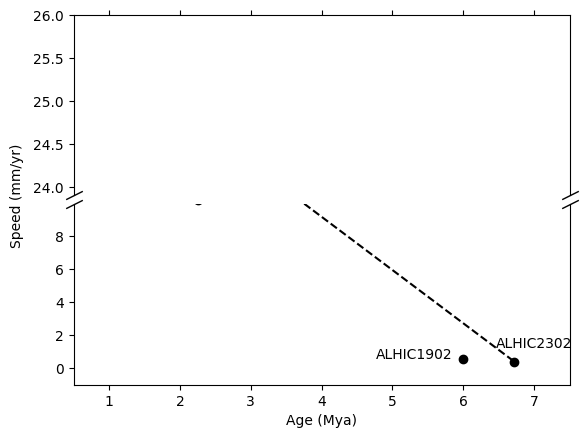

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
fig.subplots_adjust(hspace=0.05)  # adjust space between Axes

ax1.set_ylim([23.9,26])
ax2.set_ylim([-1,9.9])

ax1.set_xlim([0.5,7.5])
ax2.set_xlim([0.5,7.5])

ax1.scatter(core_age_all, speed_all, marker='o', c='black')
ax2.scatter(core_age_all, speed_all, marker='o', c='black')

ax1.spines.bottom.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # don't put tick labels at the top
ax2.xaxis.tick_bottom()

d = .5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

ax2.plot(core_age_mask[order],best_fit[order], ls='--', color='black') 

for txt, x_fig_loc, y_fig_loc in zip(core_names_all, core_age_all, speed_all):
    if txt == 'ALHIC2302':
        ax2.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(15,10), ha='center')
    elif txt == 'ALHIC1902':
        ax2.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(-35,0), ha='center')
    else:
        ax2.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(0,10), ha='center')
        ax1.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(0,10), ha='center')

ax1.set_ylabel('Speed (mm/yr)')
ax1.yaxis.set_label_coords(-.1,0)

ax2.set_xlabel('Age (Mya)')

# plt.savefig('Figures/fig3_v3.png', dpi=600)
# plt.savefig('Figures/fig3_v3.eps', dpi=600)

In [12]:
mask = ~np.isnan(core_age) & ~np.isnan(speed)
core_age_mask = np.array(core_age)[mask]
speed_mask = np.array(speed)[mask]

slope,intercept = np.polyfit(core_age_mask, np.log(speed_mask), 1)  
best_fit  = np.exp(slope * core_age_mask + intercept)

r_squared = r2_score(speed_mask, best_fit)
order = np.argsort(core_age_mask)

In [13]:
# fig,ax = plt.subplots()

# norm = plt.Normalize(0, 4)
# sm = plt.cm.ScalarMappable(cmap="Reds", norm=norm)
# cmap = plt.cm.Reds

# for ca, sp, cn in zip(core_age_all, speed_all, core_names_all):
#     if cn == 'PICO2201':
#         pass
#         # ax.semilogy(ca, sp, marker='X', c='red', ls='')
#     elif cn == 'ALHIC2401':
#         ax.semilogy(ca, sp, marker='o', c='black', ls='')
#     else:
#         color_val =  cmap(norm(geochem['d_excess mean (‰) '][cn]))
#         ax.semilogy(ca, sp, marker='o', markeredgecolor='black', c=color_val, ls='',markersize=7)

# ax.plot(core_age_mask[order],best_fit[order], ls='--', color='black') 

# for txt, x_fig_loc, y_fig_loc in zip(core_names_all, core_age_all, speed_all):
#     if txt == 'ALHIC2302':
#         ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(35,-2), ha='center')
#     elif txt == 'ALHIC1902':
#         ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(-35,0), ha='center')
#     elif txt == 'ALHIC1502':
#         ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(-35,0), ha='center')
#     elif txt == 'ALHIC1901':
#         ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(35,0), ha='center')
#     elif txt == 'ALHIC2201':
#         ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(20,10), ha='center')
#     elif txt == 'PICO2201':
#         pass
#         # ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(20,10), ha='center')
#     else:
#         ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(0,10), ha='center')

# ax.set_xlim([0.1,8.2])
# ax.set_ylim([10e-2, 50])
# ax.set_ylabel('Speed (mm/yr)')
# ax.set_xlabel('Age (Mya)')

# cbar = plt.colorbar(sm, ax=ax, ticks=np.linspace(0, 4,5), fraction=0.046, shrink=0.4, label='$d_{excess}$ mean ($^o/_{oo}$)')

# ax.grid( which='major', color='gray', linestyle='-')
# ax.grid( which='minor', color='lightgray', linestyle='-')
# # plt.savefig('Figures/fig3_v3.png', dpi=600)
# # plt.savefig('Figures/fig3_v3.eps', dpi=600)

In [14]:
# fig,ax = plt.subplots()

# norm = plt.Normalize(0.5, 3.5)
# sm = plt.cm.ScalarMappable(cmap="Reds", norm=norm)
# cmap = plt.cm.Reds

# for ca, sp, cn in zip(core_age_all, speed_all, core_names_all):
#     if cn == 'PICO2201':
#         pass
#         # ax.semilogy(ca, sp, marker='X', c='red', ls='')
#     elif cn == 'ALHIC2401':
#         ax.semilogy(ca, sp, marker='o', c='black', ls='')
#     else:
#         color_val =  cmap(norm(geochem['d_excess σ (‰)'][cn]))
#         ax.semilogy(ca, sp, marker='o', markeredgecolor='black', c=color_val, ls='',markersize=7)

# ax.plot(core_age_mask[order],best_fit[order], ls='--', color='black') 

# for txt, x_fig_loc, y_fig_loc in zip(core_names_all, core_age_all, speed_all):
#     if txt == 'ALHIC2302':
#         ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(35,-2), ha='center')
#     elif txt == 'ALHIC1902':
#         ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(-35,0), ha='center')
#     elif txt == 'ALHIC1502':
#         ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(-35,0), ha='center')
#     elif txt == 'ALHIC1901':
#         ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(35,0), ha='center')
#     elif txt == 'ALHIC2201':
#         ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(20,10), ha='center')
#     elif txt == 'PICO2201':
#         pass
#         # ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(20,10), ha='center')
#     else:
#         ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(0,10), ha='center')

# ax.set_xlim([0.1,8.2])
# ax.set_ylim([-10, 50])
# ax.set_ylabel('Speed (mm/yr)')
# ax.set_xlabel('Age (Mya)')

# cbar = plt.colorbar(sm, ax=ax, ticks=np.linspace(0.5, 3.5,5), fraction=0.046, shrink=0.4, label='$d_{excess}$ σ ($^o/_{oo}$)')

# Notes from meeting with Eric

- We need ages at each depth interval (where available) for each of the ice cores
- We should probably be comparing the geochemistry data from the same age intervals for the most 1 to 1 comparison.
- Double check ages of ALHIC1502 (did we give 1503 data by mistake?), this looks ok actually.

Summary
- Eric to reach out to Sarah and John to get more available data and ages
    - Get all the ages compiled
    - Eric to talk to Sarah and John about data quality and what their procedure is
- Eric says d_excess is probably not that informative (and its likely 2301 and the front range cores are more similar than initially thought - there are large standard deviations on the order of the mean values we are using)

<>:43: SyntaxWarning: invalid escape sequence '\d'
<>:43: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1117267/3809444020.py:43: SyntaxWarning: invalid escape sequence '\d'
  cbar = plt.colorbar(sm, ax=ax, ticks=np.linspace(0.09, .19,6), fraction=0.046, shrink=0.4, label='mean $\delta^{38}$Ar/$^{36}$Ar (<1.5 Ma, $^o/_{oo}$)')


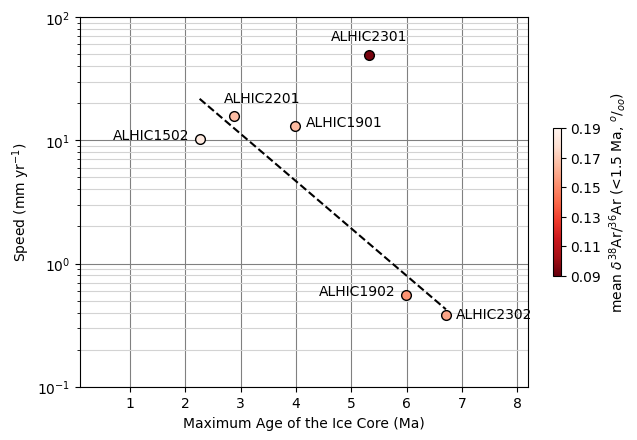

In [15]:
fig,ax = plt.subplots()

norm = plt.Normalize(.09, .19)
sm = plt.cm.ScalarMappable(cmap="Reds_r", norm=norm)
cmap = plt.cm.Reds_r

for ca, sp, cn in zip(core_age_all, speed_all, core_names_all):
    if cn == 'PICO2201':
        pass
        # ax.semilogy(ca, sp, marker='X', c='red', ls='')
    elif cn == 'ALHIC2401':
        ax.semilogy(ca, sp, marker='o', c='black', ls='')
    # elif cn == 'ALHIC1502':
    #     ax.semilogy(ca, sp, marker='x', c='black', ls='', lw=3)
    else:
        color_val =  cmap(norm(fractionation_data[cn][0]))
        ax.semilogy(ca, sp, marker='o', markeredgecolor='black', c=color_val, ls='',markersize=7)

ax.plot(core_age_mask[order],best_fit[order], ls='--', color='black') 

for txt, x_fig_loc, y_fig_loc in zip(core_names_all, core_age_all, speed_all):
    if txt == 'ALHIC2302':
        ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(35,-2), ha='center')
    elif txt == 'ALHIC1902':
        ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(-35,0), ha='center')
    elif txt == 'ALHIC1502':
        ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(-35,0), ha='center')
    elif txt == 'ALHIC1901':
        ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(35,0), ha='center')
    elif txt == 'ALHIC2201':
        ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(20,10), ha='center')
    elif txt == 'PICO2201':
        pass
        # ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(20,10), ha='center')
    else:
        ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(0,10), ha='center')

ax.set_xlim([0.1,8.2])
ax.set_ylim([10e-2, 100])
ax.set_ylabel('Speed (mm yr$^{-1}$)')
ax.set_xlabel('Maximum Age of the Ice Core (Ma)')

cbar = plt.colorbar(sm, ax=ax, ticks=np.linspace(0.09, .19,6), fraction=0.046, shrink=0.4, label='mean $\delta^{38}$Ar/$^{36}$Ar (<1.5 Ma, $^o/_{oo}$)')

ax.grid( which='major', color='gray', linestyle='-')
ax.grid( which='minor', color='lightgray', linestyle='-')
# plt.savefig('Figures/fig3_v3_d36_38Ar_enhance.png', dpi=600)
# plt.savefig('Figures/fig3_v3_d36_38Ar_enhance.eps', dpi=600)
# plt.savefig('Figures/fig3_v3_d36_38Ar_enhance.pdf', dpi=600)

<>:43: SyntaxWarning: invalid escape sequence '\d'
<>:43: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1117267/2892010719.py:43: SyntaxWarning: invalid escape sequence '\d'
  cbar = plt.colorbar(sm, ax=ax, ticks=np.linspace(-40, -36.5 ,6), fraction=0.046, shrink=0.4, label='mean $\delta^{18}$O (<1.5 Ma, $^o/_{oo}$)')


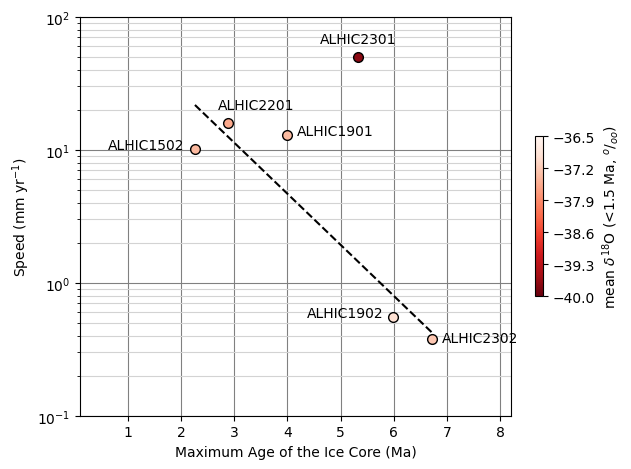

In [16]:
fig,ax = plt.subplots()

norm = plt.Normalize(-40, -36.5)
sm = plt.cm.ScalarMappable(cmap="Reds_r", norm=norm)
cmap = plt.cm.Reds_r

for ca, sp, cn in zip(core_age_all, speed_all, core_names_all):
    if cn == 'PICO2201':
        pass
        # ax.semilogy(ca, sp, marker='X', c='red', ls='')
    elif cn == 'ALHIC2401':
        ax.semilogy(ca, sp, marker='o', c='black', ls='')
    # elif cn == 'ALHIC1502':
    #     ax.semilogy(ca, sp, marker='x', c='black', ls='', lw=3)
    else:
        color_val =  cmap(norm(fractionation_data[cn][1]))
        ax.semilogy(ca, sp, marker='o', markeredgecolor='black', c=color_val, ls='',markersize=7)

ax.plot(core_age_mask[order],best_fit[order], ls='--', color='black') 

for txt, x_fig_loc, y_fig_loc in zip(core_names_all, core_age_all, speed_all):
    if txt == 'ALHIC2302':
        ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(35,-2), ha='center')
    elif txt == 'ALHIC1902':
        ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(-35,0), ha='center')
    elif txt == 'ALHIC1502':
        ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(-35,0), ha='center')
    elif txt == 'ALHIC1901':
        ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(35,0), ha='center')
    elif txt == 'ALHIC2201':
        ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(20,10), ha='center')
    elif txt == 'PICO2201':
        pass
        # ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(20,10), ha='center')
    else:
        ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(0,10), ha='center')

ax.set_xlim([0.1,8.2])
ax.set_ylim([10e-2, 100])
ax.set_ylabel('Speed (mm yr$^{-1}$)')
ax.set_xlabel('Maximum Age of the Ice Core (Ma)')

cbar = plt.colorbar(sm, ax=ax, ticks=np.linspace(-40, -36.5 ,6), fraction=0.046, shrink=0.4, label='mean $\delta^{18}$O (<1.5 Ma, $^o/_{oo}$)')

ax.grid( which='major', color='gray', linestyle='-')
ax.grid( which='minor', color='lightgray', linestyle='-')
plt.tight_layout()
# plt.savefig('Figures/fig3_v3_d18O_enhance.png', dpi=600)
# plt.savefig('Figures/fig3_v3_d18O_enhance.eps', dpi=600)
# plt.savefig('Figures/fig3_v3_d18O_enhance.pdf', dpi=600)

In [17]:
x_coords_mesh, y_coords_mesh = np.unique(mesh_fine.coordinates.dat.data_ro[:,0]), np.unique(mesh_fine.coordinates.dat.data_ro[:,1])
bed_of_mesh_coords = []
for x_co in x_coords_mesh:
    for y_co in y_coords_mesh:
        z_s =[]
        for x,y,z in zip(mesh_fine.coordinates.dat.data_ro[:,0], mesh_fine.coordinates.dat.data_ro[:,1], mesh_fine.coordinates.dat.data_ro[:,2]):

            if (x_co, y_co) == (x,y):
                z_s.append(z)

        z_min = np.array(z_s).min()

        bed_of_mesh_coords.append((x_co, y_co, z_min))

bed_of_mesh_coords_arr = np.array(bed_of_mesh_coords)


In [18]:
m_above_bed = 10

coords = []
speed_all = []

for x_bed_coord, y_bed_coord, z_bed_coord in bed_of_mesh_coords_arr:
    try:
        velocity_ms = flow.at((x_bed_coord, y_bed_coord, z_bed_coord+m_above_bed))

        coords.append((x_bed_coord, y_bed_coord, z_bed_coord))
        speed_all.append(np.sqrt((velocity_ms[0][0]*enhancement_factor)**2 + (velocity_ms[0][1]*enhancement_factor)**2 + (velocity_ms[0][2]*enhancement_factor)**2))
    
    except Exception as e: 
        # print(e)
        continue


In [19]:
age_predicted = ((np.array(speed_all) * spy * 1000) - intercept) / slope

Text(0.7, 0.3, 'Submerged Ridge')

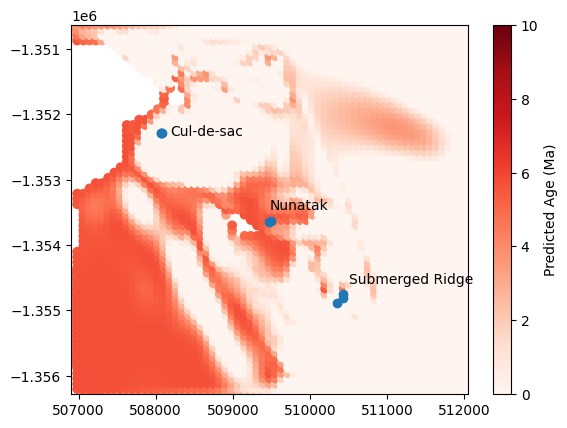

In [20]:
norm = plt.Normalize(0, 10)
sm = plt.cm.ScalarMappable(cmap="Reds", norm=norm)
cmap = plt.cm.Reds

fig,ax = plt.subplots()
sc = ax.scatter(np.array(coords)[:,0],np.array(coords)[:,1], c=age_predicted, cmap=cmap, norm=norm)
cbar = plt.colorbar(sc, label='Predicted Age (Ma)')

ax.scatter(transformed_x, transformed_y)

ax.set_xlim([np.array(coords)[:,0].min(), np.array(coords)[:,0].max()])
ax.set_ylim([np.array(coords)[:,1].min(), np.array(coords)[:,1].max()])

ax.annotate(text='Cul-de-sac', xy=(.25,.7), xycoords='axes fraction')
ax.annotate(text='Nunatak', xy=(.5,.5), xycoords='axes fraction')
ax.annotate(text='Submerged Ridge', xy=(.7,.3), xycoords='axes fraction')

In [21]:
dummy_arr = np.empty((len(np.unique(np.array(coords)[:,0])), len(np.unique(np.array(coords)[:,1]))))
dummy_arr[:] = np.nan

In [22]:
for n_x, x_ in enumerate(np.unique(np.array(coords)[:,0])):
    for n_y, y_ in enumerate(np.unique(np.array(coords)[:,1])):
        for coords_i, data_ in zip(coords, age_predicted):
            if (coords_i[0] == x_ and coords_i[1] == y_):
                dummy_arr[n_x, n_y] = data_

# for i in np.array(coords):
#     print(i)

/usr/local/lib/python3.12/dist-packages/pyproj/transformer.py:817: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return self._transformer._transform_point(
/tmp/ipykernel_1117267/1532263857.py:14: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(transformed_x_, transformed_y_, marker='o', s=50, edgecolor='black', c=color_val_, norm=norm)
/tmp/ipykernel_1117267/1532263857.py:14: UserWarning: No data for colormapping provided via 'c'. Parameters 'norm' will be ignored
  ax.scatter(transformed_x_, transformed_y_, marker='o', s=50, edgecolor='black', c=color_val_, norm=norm)


(-1355100.0, -1352500.0)

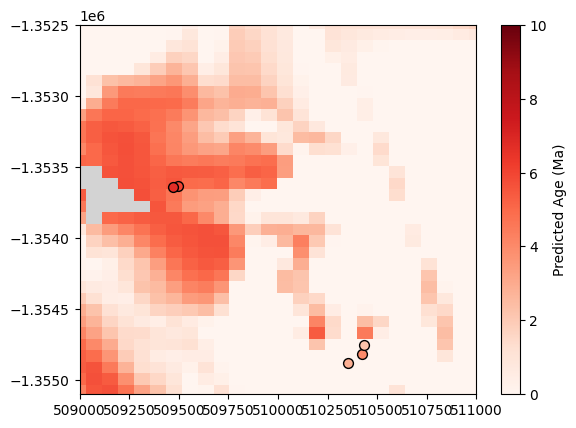

In [23]:
norm = plt.Normalize(0, 10)
sm = plt.cm.ScalarMappable(cmap="Reds", norm=norm)
cmap = plt.cm.Reds
cmap.set_bad('lightgrey')

fig,ax = plt.subplots()
im = ax.pcolormesh(np.unique(np.array(coords)[:,0]),np.unique(np.array(coords)[:,1]), dummy_arr.T, cmap=cmap, shading='nearest', vmin=0, vmax=10)
cbar = plt.colorbar(im, label='Predicted Age (Ma)')

for ca, sp, cn in zip(core_age_all, speed_all, core_names_all):
        borehole_ = borehole_locations[borehole_locations['Core'] == cn]
        transformed_x_, transformed_y_ = transformer.transform(borehole_['E'], borehole_['S'])
        color_val_ = cmap(norm(ca))
        ax.scatter(transformed_x_, transformed_y_, marker='o', s=50, edgecolor='black', c=color_val_, norm=norm)

ax.set_xlim([509000, 511000])
ax.set_ylim([-1.3551e6, -1.3525e6])

In [24]:
core_age_all = []
speed_all = []
core_names_all = []

z_vals = mesh_fine.coordinates.dat.data_ro[:,2]
depth_values = np.arange(z_vals.min(), z_vals.max(), 1)

for x_bore,y_bore,age, core_name in zip(transformed_x, transformed_y, borehole_locations['oldest ice'], borehole_locations['Core']):
    if core_name == 'ALHIC1903':
        continue
    if core_name == 'ALHIC2401':
        continue
    if core_name == 'PICO2201':
        continue
    sampled_speed_prof = []
    z_depth_prof = []

    for z_bore in depth_values:
        try:
            vels = flow.at((x_bore, y_bore, z_bore))
        except:
            continue
        sampled_speed = np.sqrt(vels[0][0]**2 + vels[0][1]**2 + vels[0][2]**2)*spy*1000*enhancement_factor
        sampled_speed_prof.append(sampled_speed)
        z_depth_prof.append(z_bore)

    z_depth_prof = np.array(z_depth_prof)
    sampled_speed_prof = np.array(sampled_speed_prof)

    speed_all.append(float(sampled_speed_prof[10]))

    core_age_all.append(core_ages_dict[core_name])
    
    core_names_all.append(core_name)


# ### We do this again so we can take out the CDS cores from the best fit ###
core_age = []
speed = []
core_names = []


for x_bore,y_bore, core_name in zip(transformed_x, transformed_y,  borehole_locations['Core']):
    if core_name == 'ALHIC2301':
        continue
    if core_name == 'PICO2201':
        continue
    if core_name == 'ALHIC1903':
        continue
    if core_name == 'ALHIC2401':
        continue
    sampled_speed_prof = []
    z_depth_prof = []

    for z_bore in depth_values:
        try:
            vels = flow.at((x_bore, y_bore, z_bore))
        except:
            continue
        sampled_speed = np.sqrt(vels[0][0]**2 + vels[0][1]**2 + vels[0][2]**2)
        sampled_speed_prof.append(sampled_speed)
        z_depth_prof.append(z_bore)

    z_depth_prof = np.array(z_depth_prof)
    sampled_speed_prof = np.array(sampled_speed_prof)

    speed.append(float(sampled_speed_prof[10]*spy*1000*enhancement_factor))

    core_age.append(core_ages_dict[core_name])
    
    core_names.append(core_name)



mask = ~np.isnan(core_age) & ~np.isnan(speed)
core_age_mask = np.array(core_age)[mask]
speed_mask = np.array(speed)[mask]

slope,intercept = np.polyfit(core_age_mask, speed_mask, 1)  
best_fit  = slope * core_age_mask + intercept

r_squared = r2_score(speed_mask, best_fit)
order = np.argsort(core_age_mask)

mask = ~np.isnan(core_age) & ~np.isnan(speed)
core_age_mask = np.array(core_age)[mask]
speed_mask = np.array(speed)[mask]

slope,intercept = np.polyfit(core_age_mask, np.log(speed_mask), 1)  
best_fit  = np.exp(slope * core_age_mask + intercept)

r_squared = r2_score(speed_mask, best_fit)
order = np.argsort(core_age_mask)

<>:51: SyntaxWarning: invalid escape sequence '\d'
<>:51: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1117267/3612674297.py:51: SyntaxWarning: invalid escape sequence '\d'
  cbar = plt.colorbar(sm, ax=ax1, ticks=np.linspace(0.09, .19,6), fraction=0.046, shrink=0.4, label='mean $\delta^{38}$Ar/$^{36}$Ar (<1.5 Ma, $^o/_{oo}$)')
/usr/local/lib/python3.12/dist-packages/pyproj/transformer.py:817: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return self._transformer._transform_point(
/tmp/ipykernel_1117267/3612674297.py:69: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax2.scatter(transformed_x_, t

(-1355100.0, -1352500.0)

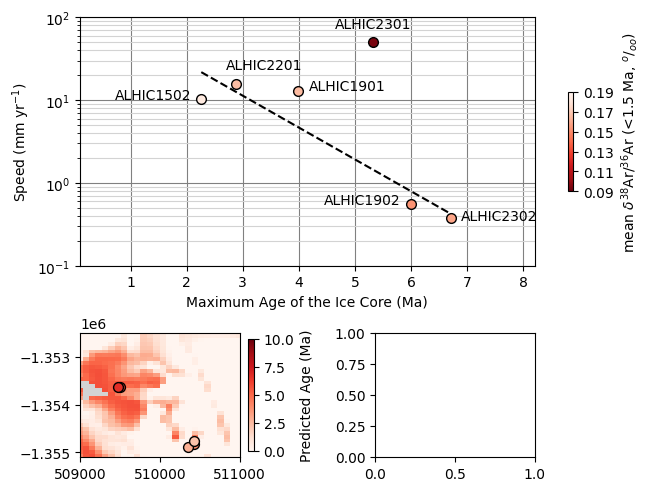

In [25]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(layout="constrained")

gs = GridSpec(3, 2, figure=fig)

ax1 = fig.add_subplot(gs[:2, :])
ax2 = fig.add_subplot(gs[2, 0])
ax3 = fig.add_subplot(gs[2, 1])

norm = plt.Normalize(.09, .19)
sm = plt.cm.ScalarMappable(cmap="Reds_r", norm=norm)
cmap = plt.cm.Reds_r

for ca, sp, cn in zip(core_age_all, speed_all, core_names_all):
    if cn == 'PICO2201':
        pass
        # ax.semilogy(ca, sp, marker='X', c='red', ls='')
    elif cn == 'ALHIC2401':
        ax1.semilogy(ca, sp, marker='o', c='black', ls='')
    # elif cn == 'ALHIC1502':
    #     ax.semilogy(ca, sp, marker='x', c='black', ls='', lw=3)
    else:
        color_val =  cmap(norm(fractionation_data[cn][0]))
        ax1.semilogy(ca, sp, marker='o', markeredgecolor='black', c=color_val, ls='',markersize=7)

ax1.plot(core_age_mask[order],best_fit[order], ls='--', color='black') 

for txt, x_fig_loc, y_fig_loc in zip(core_names_all, core_age_all, speed_all):
    if txt == 'ALHIC2302':
        ax1.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(35,-2), ha='center')
    elif txt == 'ALHIC1902':
        ax1.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(-35,0), ha='center')
    elif txt == 'ALHIC1502':
        ax1.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(-35,0), ha='center')
    elif txt == 'ALHIC1901':
        ax1.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(35,0), ha='center')
    elif txt == 'ALHIC2201':
        ax1.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(20,10), ha='center')
    elif txt == 'PICO2201':
        pass
        # ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(20,10), ha='center')
    else:
        ax1.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(0,10), ha='center')

ax1.set_xlim([0.1,8.2])
ax1.set_ylim([10e-2, 100])
ax1.set_ylabel('Speed (mm yr$^{-1}$)')
ax1.set_xlabel('Maximum Age of the Ice Core (Ma)')

cbar = plt.colorbar(sm, ax=ax1, ticks=np.linspace(0.09, .19,6), fraction=0.046, shrink=0.4, label='mean $\delta^{38}$Ar/$^{36}$Ar (<1.5 Ma, $^o/_{oo}$)')

ax1.grid( which='major', color='gray', linestyle='-')
ax1.grid( which='minor', color='lightgray', linestyle='-')

norm = plt.Normalize(0, 10)
sm = plt.cm.ScalarMappable(cmap="Reds", norm=norm)
cmap = plt.cm.Reds
cmap.set_bad('lightgrey')


im = ax2.pcolormesh(np.unique(np.array(coords)[:,0]),np.unique(np.array(coords)[:,1]), dummy_arr.T, cmap=cmap, shading='nearest', vmin=0, vmax=10)
cbar = plt.colorbar(im, label='Predicted Age (Ma)', fraction=0.046, shrink=0.9,ax=ax2, pad = -.3)

for ca, sp, cn in zip(core_age_all, speed_all, core_names_all):
        borehole_ = borehole_locations[borehole_locations['Core'] == cn]
        transformed_x_, transformed_y_ = transformer.transform(borehole_['E'], borehole_['S'])
        color_val_ = cmap(norm(ca))
        ax2.scatter(transformed_x_, transformed_y_, marker='o', s=50, edgecolor='black', c=color_val_, norm=norm)

ax2.set_xlim([509000, 511000])
ax2.set_ylim([-1.3551e6, -1.3525e6])


# plt.savefig('Figures/fig3_v3_d18O_enhance.png', dpi=600)
# plt.savefig('Figures/fig3_v3_d18O_enhance.eps', dpi=600)
# plt.savefig('Figures/fig3_v3_d18O_enhance.pdf', dpi=600)


<>:51: SyntaxWarning: invalid escape sequence '\d'
<>:51: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1117267/3208191876.py:51: SyntaxWarning: invalid escape sequence '\d'
  cbar = plt.colorbar(sm, ax=ax1, ticks=np.linspace(0.09, .19,6), fraction=0.046, shrink=0.4, label='mean $\delta^{38}$Ar/$^{36}$Ar (<1.5 Ma, $^o/_{oo}$)')
/usr/local/lib/python3.12/dist-packages/pyproj/transformer.py:817: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return self._transformer._transform_point(
/tmp/ipykernel_1117267/3208191876.py:69: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax2.scatter(transformed_x_, t

[Text(0, -1355500.0, '0'),
 Text(0, -1355000.0, '500'),
 Text(0, -1354500.0, '1000'),
 Text(0, -1354000.0, '1500'),
 Text(0, -1353500.0, '2000'),
 Text(0, -1353000.0, '2500'),
 Text(0, -1352500.0, '3000')]

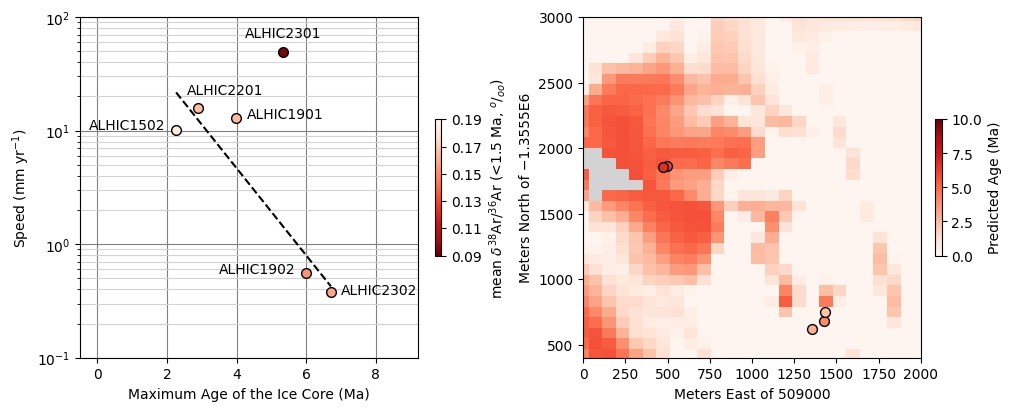

In [40]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(10, 4), layout="constrained")

gs = GridSpec(1, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])


norm = plt.Normalize(.09, .19)
sm = plt.cm.ScalarMappable(cmap="Reds_r", norm=norm)
cmap = plt.cm.Reds_r

for ca, sp, cn in zip(core_age_all, speed_all, core_names_all):
    if cn == 'PICO2201':
        pass
        # ax.semilogy(ca, sp, marker='X', c='red', ls='')
    elif cn == 'ALHIC2401':
        ax1.semilogy(ca, sp, marker='o', c='black', ls='')
    # elif cn == 'ALHIC1502':
    #     ax.semilogy(ca, sp, marker='x', c='black', ls='', lw=3)
    else:
        color_val =  cmap(norm(fractionation_data[cn][0]))
        ax1.semilogy(ca, sp, marker='o', markeredgecolor='black', c=color_val, ls='',markersize=7)

ax1.plot(core_age_mask[order],best_fit[order], ls='--', color='black') 

for txt, x_fig_loc, y_fig_loc in zip(core_names_all, core_age_all, speed_all):
    if txt == 'ALHIC2302':
        ax1.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(35,-2), ha='center')
    elif txt == 'ALHIC1902':
        ax1.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(-35,0), ha='center')
    elif txt == 'ALHIC1502':
        ax1.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(-35,0), ha='center')
    elif txt == 'ALHIC1901':
        ax1.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(35,0), ha='center')
    elif txt == 'ALHIC2201':
        ax1.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(20,10), ha='center')
    elif txt == 'PICO2201':
        pass
        # ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(20,10), ha='center')
    else:
        ax1.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(0,10), ha='center')

ax1.set_xlim([-0.5,9.2])
ax1.set_ylim([10e-2, 100])
ax1.set_ylabel('Speed (mm yr$^{-1}$)')
ax1.set_xlabel('Maximum Age of the Ice Core (Ma)')

cbar = plt.colorbar(sm, ax=ax1, ticks=np.linspace(0.09, .19,6), fraction=0.046, shrink=0.4, label='mean $\delta^{38}$Ar/$^{36}$Ar (<1.5 Ma, $^o/_{oo}$)')

ax1.grid( which='major', color='gray', linestyle='-')
ax1.grid( which='minor', color='lightgray', linestyle='-')

norm = plt.Normalize(0, 10)
sm = plt.cm.ScalarMappable(cmap="Reds", norm=norm)
cmap = plt.cm.Reds
cmap.set_bad('lightgrey')


im = ax2.pcolormesh(np.unique(np.array(coords)[:,0]),np.unique(np.array(coords)[:,1]), dummy_arr.T, cmap=cmap, shading='nearest', vmin=0, vmax=10)
cbar = plt.colorbar(im, label='Predicted Age (Ma)', fraction=0.046, shrink=0.4,ax=ax2,pad=-0.01)

for ca, sp, cn in zip(core_age_all, speed_all, core_names_all):
        borehole_ = borehole_locations[borehole_locations['Core'] == cn]
        transformed_x_, transformed_y_ = transformer.transform(borehole_['E'], borehole_['S'])
        color_val_ = cmap(norm(ca))
        ax2.scatter(transformed_x_, transformed_y_, marker='o', s=50, edgecolor='black', c=color_val_, norm=norm)

ax2.set_xlim([509000, 511000])
ax2.set_ylim([-1.3551e6, -1.3525e6])

ax2.set_xlabel('Meters East of '+ax2.get_xticklabels()[0].get_text())
ax2.set_ylabel('Meters North of '+ax2.get_yticklabels()[0].get_text()+'E6')

x_ticks_loc = [item.get_position()[0] for item in ax2.get_xticklabels()]
x_tick_labels = [int(float(item.get_text()) -  float(ax2.get_xticklabels()[0].get_text())) for item in ax2.get_xticklabels()]
ax2.set_xticks(x_ticks_loc, labels = x_tick_labels)

# ax2.set_xticklabels(x_tick_labels)

y_tick_labels = [int(float(item.get_text().replace('−','-'))*1e6 -  float(ax2.get_yticklabels()[0].get_text().replace('−','-'))*1e6) for item in ax2.get_yticklabels()]
ax2.set_yticklabels(y_tick_labels)

# Time using Zwinger 2014 finite element method

In [104]:
upscale_factor_fine = 1/10
src_bed_fine_path = "Meshes/crop_aoi/main_boreholes_aoi/main_boreholes_aoi_fix_bed.tif"
src_surf_fine_path = "Meshes/crop_aoi/main_boreholes_aoi/main_boreholes_aoi_fix_surf.tif"
layer_num=5

mesh_fine = mesh_creator(src_bed_fine_path, src_surf_fine_path, resamp_factor=upscale_factor_fine, layers=layer_num)
mesh_fine.tolerance = 1e-10
x_src, y_src, z_src = SpatialCoordinate(mesh_fine)

pressure_space = firedrake.FunctionSpace(mesh_fine, "CG", 1)
velocity_space = firedrake.VectorFunctionSpace(mesh_fine, "CG", 3)
Y = velocity_space * pressure_space
flow = firedrake.Function(Y)

chk = DumbCheckpoint("Saved_Models/fine_mesh_flow_80.0m_updated_viscosity", mode=FILE_READ)
chk.load(flow, name="fine_mesh_flow")

/opt/firedrake/firedrake/checkpointing.py:103: DeprecationWarning: DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.",


In [25]:
u, p = firedrake.split(flow)

In [40]:
δx = mesh_fine.cell_sizes.dat.data_ro[:].min()
umax = flow.sub(0).dat.data_ro[:].max()
δt = Constant(spy/.00001)

from ufl import Measure
dx = ufl.Measure('dx', domain=mesh_fine)

V = firedrake.FunctionSpace(mesh_fine, "CG", 1)

ψ = firedrake.Function(V)

ϕ = firedrake.TestFunction(V)

F = Dt(ψ) * ϕ * dx + ψ * inner(u, grad(ϕ)) * dx

In [41]:
bcs = []

for face in [1,2,3,4]:
    bcs.append(firedrake.DirichletBC(V, 10e3, face))

In [ ]:
method = irksome.BackwardEuler()
age_dis_solver = irksome.TimeStepper(F, method, Constant(1.0), δt, ψ, bcs=bcs)

In [65]:
import tqdm
final_time = 10e5* spy 
num_steps = int(final_time / float(δt))
ψs = [ψ.copy(deepcopy=True)]

ts = np.linspace(0.0, final_time, num_steps + 1)

for step in tqdm.trange(num_steps):
    t = ts[step]


    age_dis_solver.advance()


    ψs.append(ψ.copy(deepcopy=True))


100%|██████████| 10/10 [00:24<00:00,  2.40s/it]


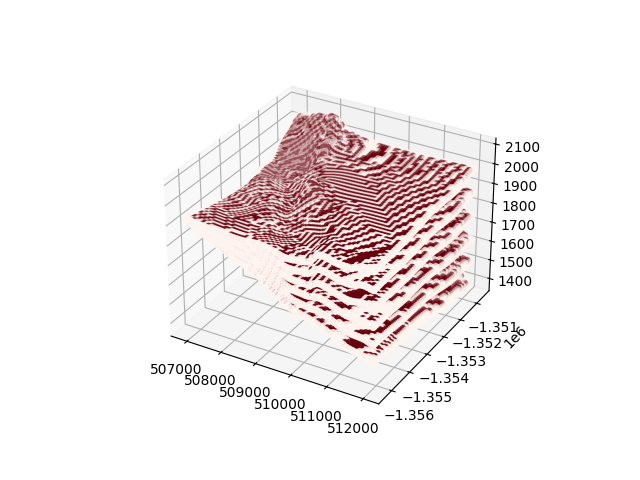

In [ ]:
norm = plt.Normalize(0, 10)
sm = plt.cm.ScalarMappable(cmap="Reds", norm=norm)
cmap = plt.cm.Reds

ax = plt.figure().add_subplot(projection='3d')
ax.scatter(mesh_fine.coordinates.dat.data_ro[:,0], 
mesh_fine.coordinates.dat.data_ro[:,1], 
mesh_fine.coordinates.dat.data_ro[:,2],
c = ψs[-3].dat.data_ro[:]/10e6, cmap=cmap, norm=norm)

# Get the surface ages from figure 3

In [ ]:
coordinates_in_3d = np.reshape(np.array(mesh_fine.coordinates.dat.data_ro[:]), (np.unique(mesh_fine.coordinates.dat.data_ro[:,0]).shape[0], np.unique(mesh_fine.coordinates.dat.data_ro[:,1]).shape[0],6,3))

In [112]:
for i in coordinates_in_3d:

SyntaxError: incomplete input (1112341857.py, line 1)

array([[[[  506902.38391538, -1356284.4702338 ,     1915.30476457],
         [  506902.38391538, -1356284.4702338 ,     1916.13455873],
         [  506902.38391538, -1356284.4702338 ,     1916.96435288],
         [  506902.38391538, -1356284.4702338 ,     1917.79414704],
         [  506902.38391538, -1356284.4702338 ,     1918.6239412 ],
         [  506902.38391538, -1356284.4702338 ,     1919.45373535]],

        [[  506902.38391538, -1356203.68150141,     1913.12788626],
         [  506902.38391538, -1356203.68150141,     1914.08968694],
         [  506902.38391538, -1356203.68150141,     1915.05148762],
         [  506902.38391538, -1356203.68150141,     1916.01328829],
         [  506902.38391538, -1356203.68150141,     1916.97508897],
         [  506902.38391538, -1356203.68150141,     1917.93688965]],

        [[  506982.75314615, -1356284.4702338 ,     1907.60749868],
         [  506982.75314615, -1356284.4702338 ,     1909.56998332],
         [  506982.75314615, -1356284.470233

# Notes with Brad (5/19/26)

In [ ]:
# Add a table of the GPS velocities in the appendix
# Rewrite for GRL
